# 1) Density method - SIMP

____
|**<u>Indicative duration</u>** : 1 hour 30 minutes
|---|

There are 4 types of code cells:
- **<font color='green'>[RUN & OBSERVE]</font>** $\rightarrow$ the cell should be run directly without modification
- **<font color='orange'>[RUN & PLAY]</font>** $\rightarrow$ the cell can be run directly, but some parameters should be changed interactively
- **<font color='red'>[FILL & RUN]</font>**    $\rightarrow$ the cell should be filled before being run
- **<font color='magenta'>[FILL & PLAY]</font>** $\rightarrow$ the cell should be filled, and then some parameters should be changed interactively.

____
## A) Problem definition

|**<u>Indicative duration</u>** : 30 minutes|
|---|

The objective is to design a **<u>transformer</u>**, so to distribute iron in order to **<u>maximize the magnetic flux</u>** that is coming from the primary winding into the secondary winding.

### i) Design domain

Consider the 2D domain $\Omega$ with a boundary $\partial \Omega$, containing a primary winding $P$ with back-and-forth conductors $P_+$ and $P_-$, as well as a secondary winding with back-and-forth conductors $S_+$ and $S_-$. 
The coils are fixed and the design zone is called $\Omega_c$.

![Capture d'écran 2026-03-09 071646.png](<attachment:Capture d'écran 2026-03-09 071646.png>)

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|
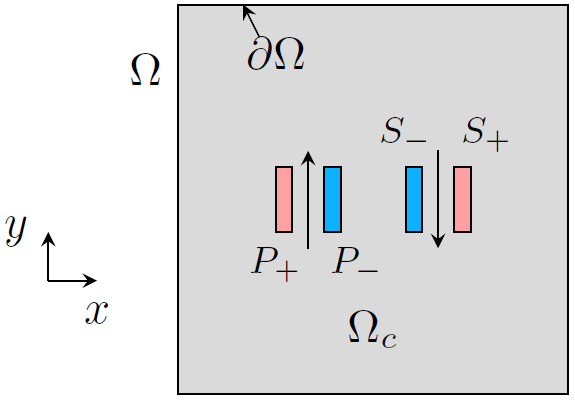

In [2]:
###############################################################################
## CODE CELL 1 : Import transformer mesh
###############################################################################

from utils.geometry import transformer
from ngsolve.webgui import Draw

mesh = transformer(maxh = 0.1)                   #  mesh the transformer geometry
print(f"Region names : {mesh.GetMaterials()}")   # display the regions (materials) labels
print(f"Line names : {mesh.GetBoundaries()}")    # display the lines (boundaries) labels
Draw(mesh)

Region names : ('Omega_c', 'Pp', 'Pm', 'Sm', 'Sp')
Line names : ('dOmega', 'dOmega', 'dOmega', 'dOmega', 'dPp', 'dPp', 'dPp', 'dPp', 'dPm', 'dPm', 'dPm', 'dPm', 'dSm', 'dSm', 'dSm', 'dSm', 'dSp', 'dSp', 'dSp', 'dSp')


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

### ii) Density

To define the core geometry, we introduce a so-called **density field** $\rho:\Omega_c \rightarrow [0,1]$ which is the **optimization variable**, so that:
- $\rho=0$ is associated with **<u>air</u>** with a magnetic reluctivity $\nu_{air} = 1/\mu_{air}$, and $\mu_{air} = \mu_0 = 4\times 10^{-7} H/m$
- $\rho=1$ is associated with **<u>iron</u>** with a magnetic reluctivity $\nu_{iron} = 1/(\mu_r\mu_{air})$ and $\mu_r=1000$
- **intermediate magnetic properties** are **<u>interpolated</u>** on intermediate $\rho$ values 

There is some freedom on the choice of $\nu$ interpolation. An usual choice is to use a power law, also called "SIMP" interpolation:

$$ \nu(\rho) = \nu_{air} + \rho^p (\nu_{iron} - \nu_{air}),$$

with $p\geq 1$. It is not the only possibility, for instance we can also interpolate the magnetic permeability $\mu=1/\nu$:
$$ \mu(\rho) = \mu_{air} + \rho^p (\mu_{iron} - \mu_{air}),$$

which gives the following $\nu$-interpolation
$$\nu(\rho) = \frac{1}{\frac{1}{\nu_{air}} + \rho^p (\frac{1}{\nu_{iron}} - \frac{1}{\nu_{air}}) }.$$

Many other choices are possible, see for instance [10.1016/j.jmmm.2025.173646](https://doi.org/10.1016/j.jmmm.2025.173646), [10.1108/COMPEL-04-2017-0170](https://doi.org/10.1108/COMPEL-04-2017-0170).

For now, we chose $p=1$, we'll see its influence later.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

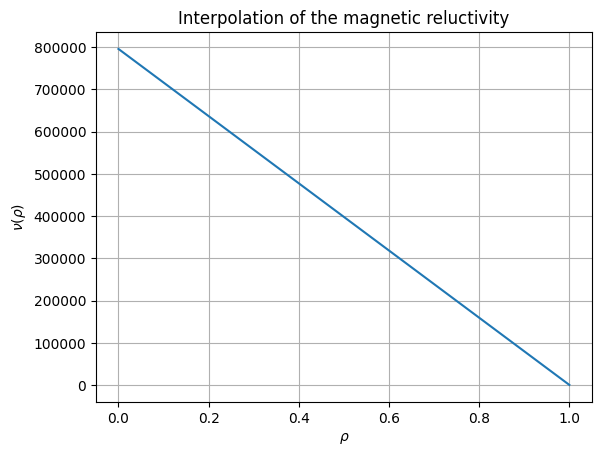

In [10]:
###############################################################################
## CODE CELL 2 : Define interpolation of the magnetic reluctivity
###############################################################################

from numpy import pi
mu0 = 4e-7 * pi   # magnetic permeability of air (H/m)
mur = 1000        # relative magnetic permeability of the iron    
p = 1

def nu(rho, p=1):
    """ reluctivity depending on the density """
    return 1/mu0 + rho**p * (1/(mu0*mur) - 1/mu0)  # power law interpolation of nu
    # return 1/ (mu0 + rho**p * (mur*mu0 -mu0))    # power law interpolation of mu

# Plot the interpolation
import matplotlib.pyplot as plt
import numpy as np

rho = np.linspace(0,1,100)
plt.plot(rho, nu(rho,p)); plt.xlabel("$\\rho$"); 
plt.ylabel("$\\nu(\\rho)$"); plt.grid(); 
plt.title("Interpolation of the magnetic reluctivity")
plt.show()

### iii) Magnetic state

The magnetic state depends on the density field $\rho$ implicitely by solving the state equation

$$
\text{find $a_\rho \in H^1_0(\Omega)$, such that }
$$
$$
\forall v \in H^1_0(\Omega), \quad \int_\Omega \text{curl}\;v \cdot \nu(\rho) \text{curl}\;a_\rho = \int_{P_+} v j_z - \int_{P_-} v j_z,
$$

with $j_z = 10^6 A/m²$. To highligh the implicit dependance in $\rho$, we write $a_\rho$, while when a magnetic state is decorrelated from $\rho$ we write $a_z$. 

Look at [this notebook](1_FEM_forward_problem.ipynb) to see how to implement the abovementioned magnetostatic weak formulation, and this [cheat sheet](B_NGSolve_cheat_sheet.ipynb) for a reminder of NGSolve syntax.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [12]:
###############################################################################
## CODE CELL 3 : Define the magnetostatic solver
###############################################################################

from ngsolve import CF, grad

def curl(v):
    R = CF(((0,1),(-1,0)), dims = (2,2))  # Rotation matrix of angle -pi/2
    return R * grad(v)

from ngsolve import H1, BilinearForm, LinearForm, dx
from utils.solver import solve

jz = 1e6 # current density in the primary coil (A/m²)
def state(rho):
    """ Solve the state equation for a given density field rho """
    fes = H1(mesh, order = 1, dirichlet = "out")
    a, v = fes.TnT()    # define the trial and test functions 
    bf = BilinearForm(curl(v) * (nu(rho) * curl(a)) * dx)  
    lf = LinearForm(jz * v * dx("Pp") - jz * v * dx("Pm"))
    return solve(bf, lf)

# Test your function
arho, Kinv = state(0)
Draw(arho)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

### iv) Objective function

We want to maximize the magnetic flux, which is
$$\phi(a_z) = L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} a_z - \frac{1}{|S^-|}\int_{S^-} a_z \right)$$
with $N_s$ the number of turns of the secondary winding, and $L_z$ the length of the transformer in the $z$ direction (normalized to $L_z = 1m$ here). To comply with optimization customs and traditions, we define 
$$f := -\phi$$
the objective function to **<u>minimize</u>**.


In [13]:
###############################################################################
## CODE CELL 18 : Compute the flux
###############################################################################

from ngsolve import Integrate

def flux(sol, Ns = 100, Lz = 1):
    """ Compute the flux in the secondary coil """
    Sp = Integrate(1, mesh, definedon = mesh.Materials("Sp"))
    Sm = Integrate(1, mesh, definedon = mesh.Materials("Sm"))
    aSp = Integrate(sol, mesh, definedon = mesh.Materials("Sp"))
    aSm = Integrate(sol, mesh, definedon = mesh.Materials("Sm"))
    return Ns * Lz * (aSp/Sp - aSm/Sm)

def f(sol):
    """ Objective function to minimize """
    return -flux(sol)

# Test your function
print(f"Secondary flux = {flux(arho):.3e} Wb/m")

Secondary flux = 6.275e-04 Wb/m


### v) Optimization problem

We are now able to state the optimization problem mathematically:

$$\text{find}\; \rho^* = \arg \min_{\rho:\Omega_c\rightarrow [0,1]} - L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} a_\rho - \frac{1}{|S^-|}\int_{S^-} a_\rho \right)$$

with 
$$\forall v \in H^1_0(\Omega), \quad \int_\Omega \text{curl}\;v \cdot \nu(\rho) \text{curl}\;a_\rho = \int_{P_+} v j_z - \int_{P_-} v j_z$$

We can solve this problem numerically with a **<u>gradient descent</u>**.